In [1]:
from typing import Annotated, TypedDict, Literal, List
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Command, CachePolicy, interrupt, Send
from langgraph.runtime import Runtime
from langgraph.types import RetryPolicy, TimeoutPolicy
from langgraph.errors import NodeError
from langchain_core.messages import (
    BaseMessage, SystemMessage, HumanMessage, ToolMessage
)
from langchain.chat_models import init_chat_model
from langchain.tools import tool
from IPython.display import Image, display
from operator import add
from dotenv import load_dotenv
from pydantic.dataclasses import dataclass
from pydantic import BaseModel, Field

load_dotenv()

def display_graph(graph, xray=False):
    """显示图结构，xray = True 可展开子图内部结构"""
    display(Image(graph.get_graph(xray = xray).draw_mermaid_png()))

llm = init_chat_model("deepseek-chat")

# 1. 顺序执行（Prompt Chaining）

Prompt Chaining 是最基础的编排模式：前一个LLM的输出作为后一个LLM的输入，像流水线一样串联起来。

与直接 LLM 调用的区别: 顺序链可以在步骤之间加入验证门控（Gate）——如果某步质量不达标就退回重做，而不是一路到底。

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field

class JokeState(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str

def generate_joke(state: JokeState):
    """生成初稿"""
    msg = llm.invoke(f"write a short joke about {state['topic']}")
    return {"joke": msg.content, "final_joke": msg.content}

def check_punchline(state: JokeState):
    """门控函数：检查笑话是否有笑点"""
    msg = llm.invoke(f"Check if the joke has punchline and wordplay, return 'Pass' or 'Fail' for the joke: ```{state['joke']}```")
    result = msg.content

    if "Pass" == result:
        print(f"[检查]通过✅️")
        return "Pass"
    print(f"[检查]不通过❌️")
    return "Fail"

def improve_joke(state: JokeState):
    """改进——增加双关语"""
    print(f"  [润色] 添加双关语...")
    msg = llm.invoke(f"Make this joke funnier by adding wordplay: {state['joke']}")
    return {"improved_joke": msg.content}


def polish_joke(state: JokeState):
    """步骤3: 润色——加一个反转"""
    print(f"  [润色] 添加反转...")
    msg = llm.invoke(f"Add a surprising twist to this joke: {state['improved_joke']}")
    return {"final_joke": msg.content}


chaining_graph = (
    StateGraph(JokeState)
    .add_node("generate_joke", generate_joke)
    .add_node("improve_joke", improve_joke)
    .add_node("polish_joke", polish_joke)

    .add_edge(START, "generate_joke")
    # 条件边：通过则直接结束，不通过则进入改进流程
    .add_conditional_edges(
        "generate_joke",
        check_punchline,
        {"Pass": END, "Fail": "improve_joke"}
    )
    .add_edge("improve_joke", "polish_joke")
    .add_edge("polish_joke", END)
    .compile()
)

print("=== 测试1: 话题「大树」 ===\n")
r = chaining_graph.invoke({"topic": "大树", "joke": "", "improved_joke": "", "final_joke": ""})
print(f"\n最终笑话:\n{r['final_joke']}")

# 2. 并行执行（Parallelization）

通过并行化，可以让多个LLM同时处理一个任务，有两种不同的实现方式和作用：
- 提高效率: 将任务拆分为子任务，让多个LLM同时运行独立的子任务来完成，再汇总结果
- 提高准确度: 多个LLM运行相同的任务产生不同的输出，再合并优化结果

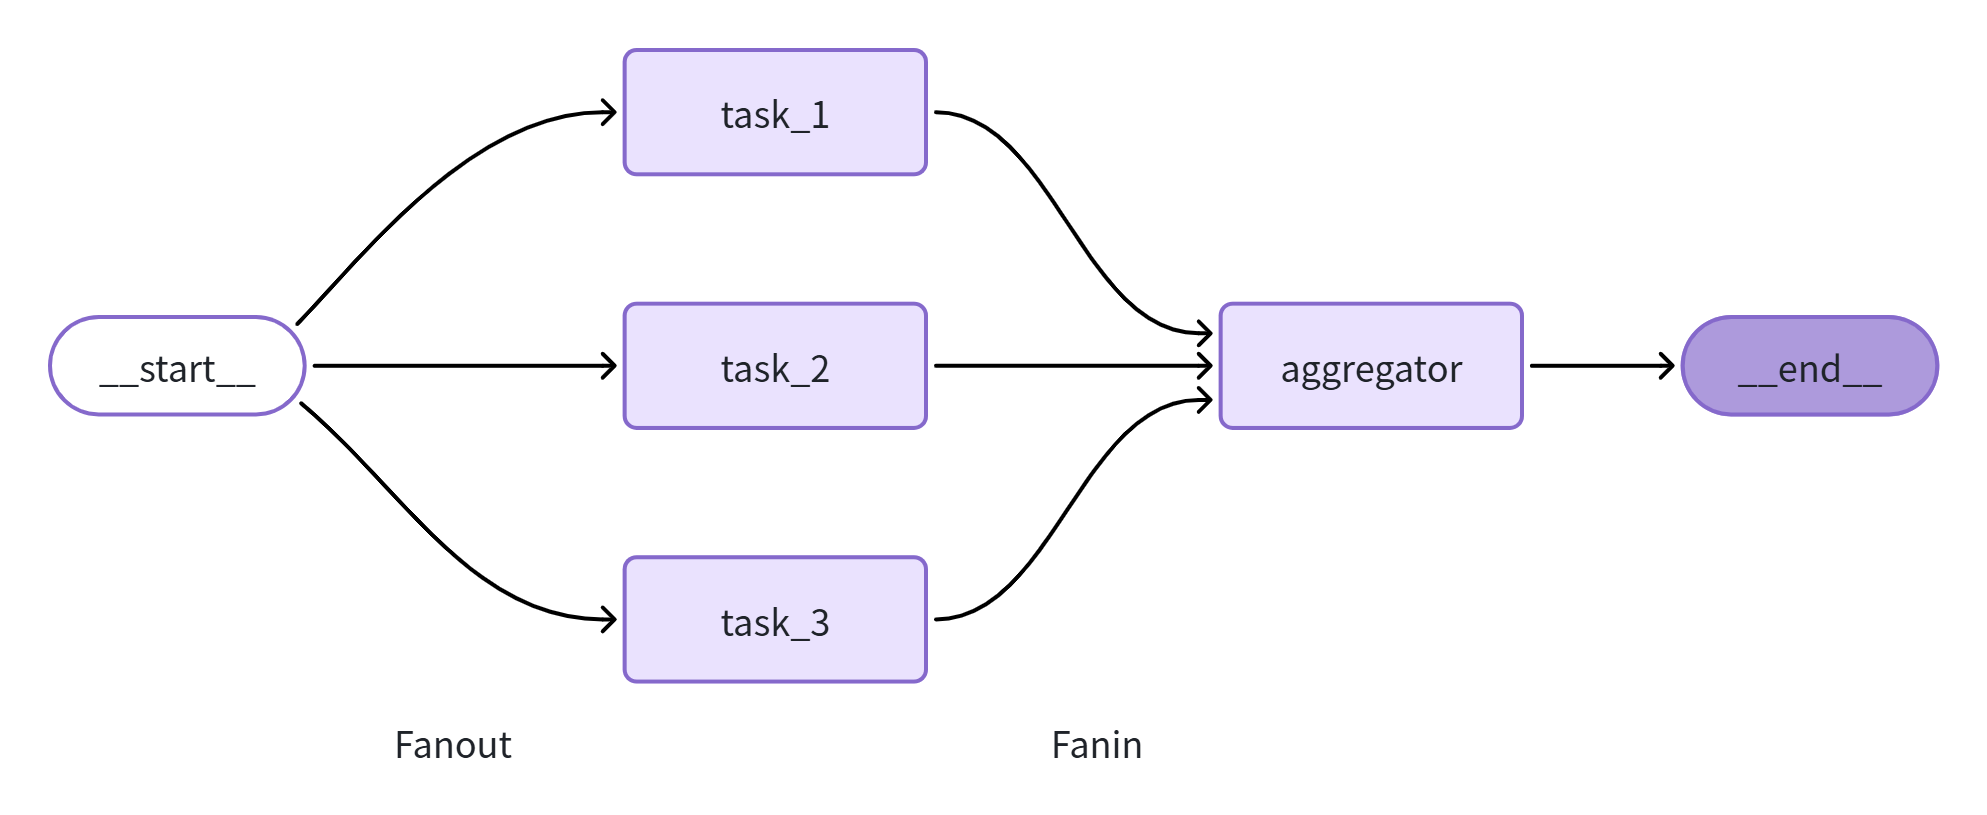

In [ ]:
class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    combined_output: str

# Nodes
def joke_node(state: State):
    """First LLM call to generate initial joke"""
    msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}

def story_node(state: State):
    """Second LLM call to generate story"""
    msg = llm.invoke(f"Write a story about {state['topic']}")
    return {"story": msg.content}

def poem_node(state: State):
    """Third LLM call to generate poem"""
    msg = llm.invoke(f"Write a poem about {state['topic']}")
    return {"poem": msg.content}

def aggragator(state: State):
    """Combine the joke, story and poem into a single output"""
    combined = f"Here's a story, joke, and poem about {state['topic']}!\n\n"
    combined += f"STORY:\n{state['story']}\n\n"
    combined += f"JOKE:\n{state['joke']}\n\n"
    combined += f"POEM:\n{state['poem']}"

    return {"combined_output": combined}

# Build workflow
parallel_builder = StateGraph(State)

# Add nodes
parallel_builder.add_node("joke", joke_node)
parallel_builder.add_node("story", story_node)
parallel_builder.add_node("poem", poem_node)
parallel_builder.add_node("aggregator", aggragator)

# Add edges to connect nodes
parallel_builder.add_edge(START, "joke")
parallel_builder.add_edge(START, "story")
parallel_builder.add_edge(START, "poem")
parallel_builder.add_edge("joke", "aggregator")
parallel_builder.add_edge("story", "aggregator")
parallel_builder.add_edge("poem", "aggregator")
parallel_builder.add_edge("aggregator", END)
parallel_workflow = parallel_builder.compile()

display_graph(parallel_workflow)

# 3. 路由（Routing）

Routing工作流处理用户输入，然后将它们引导到上下文相关的任务Node。这允许您为复杂的任务定义专门的流。例如：
- 智能电商客服，首先识别问题的类型，然后将请求路由到 售前咨询、退款、退货等对应的Node。
- 知识问答机器人，首先识别问题知识领域，然后将请求路由到不同领域对应的专业Node上。

所以路由本质上也是条件分支，让Graph根据问题动态选择下一节点。这是Agent智能决策的核心机制。

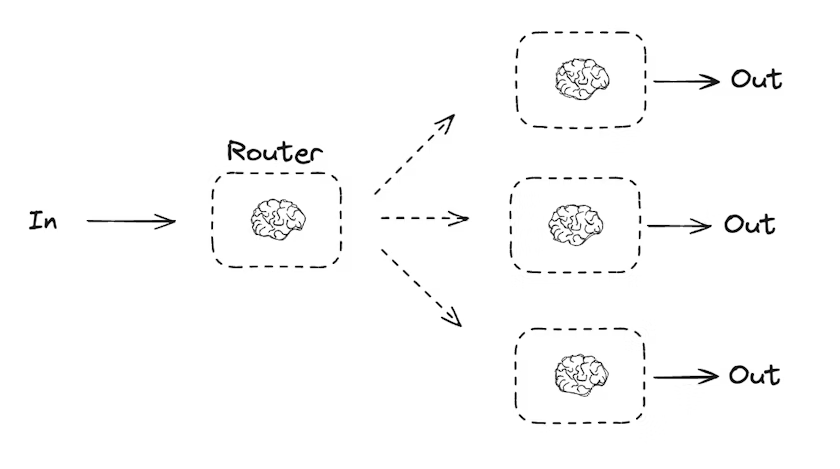

写三个工作节点：
- 天气节点：可以查询天气
- 新闻节点：可以查询新闻
- 翻译节点：可以翻译

然后写一个意图识别节点，根据用户意图路由到对应的工作节点，执行对应任务：

In [ ]:
from typing import Literal, TypedDict
from langgraph.graph import StateGraph, START, END
from langchain.messages import HumanMessage, SystemMessage

# 定义作为路由逻辑的结构化输出模型
class Route(BaseModel):
    step: Literal["weather", "translate", "chat"] = Field(
        None, description="The next step in the routing process"
    )

# 把路由结构化输出绑定到模型，形成一个用于路由的llm
# 这行是在给 LLM 绑定一个结构化输出格式，让它返回的不是自由文本，而是符合 Route schema 的对象。
router = llm.with_structured_output(Route)

class IntentState(TypedDict):
    query: str
    intent: str
    result: str

def classify_intent(state: IntentState):
    """分类用户意图"""
    # Run the augmented LLM with structured output to serve as routing logic
    decision = router.invoke(  # decision 是 Route 实例
        [
            SystemMessage(
                content= "Route the input to weather, translate, or chat based on the user's request."
            ),
            HumanMessage(content=state["query"])
        ]
    )

    return {"intent": decision.step}

def handle_weather(state: IntentState):
    return {"result": f"天气查询: {state['query']} -> 晴 25度"}

def handle_translate(state: IntentState):
    return {"result": f"翻译: {state['query']} -> Hello World"}

def handle_chat(state: IntentState):
    return {"result": f"闲聊: {state['query']} -> 你好呀！"}

def intent_router(state: IntentState) -> Literal["weather", "translate", "chat"]:
    """根据意图路由到不同处理器"""
    return state['intent']

routing_graph = (
    StateGraph(IntentState)
    .add_node("classify", classify_intent)
    .add_node("weather", handle_weather)
    .add_node("translate", handle_translate)
    .add_node("chat", handle_chat)

    .add_edge(START, "classify")
    .add_conditional_edges(
        "classify",
        intent_router,
        {
            "weather": "weather",
            "translate": "translate",
            "chat": "chat"
        }
    )
    .add_edge("weather", END)
    .add_edge("translate", END)
    .add_edge("chat", END)

    .compile()
)

display_graph(routing_graph)

# 4. Orchestrator-Worker + Send API

Orchestrator-Worker，顾名思义，编排器—工作者模型。分为三个步骤：
- 编排器（Orchestrator）：将任务分解为子任务，将子任务分配给worker
- 工作节点（Worker）：并行执行任务
- 合成器（Synthesizer）：将worker的输出汇总为最终结果

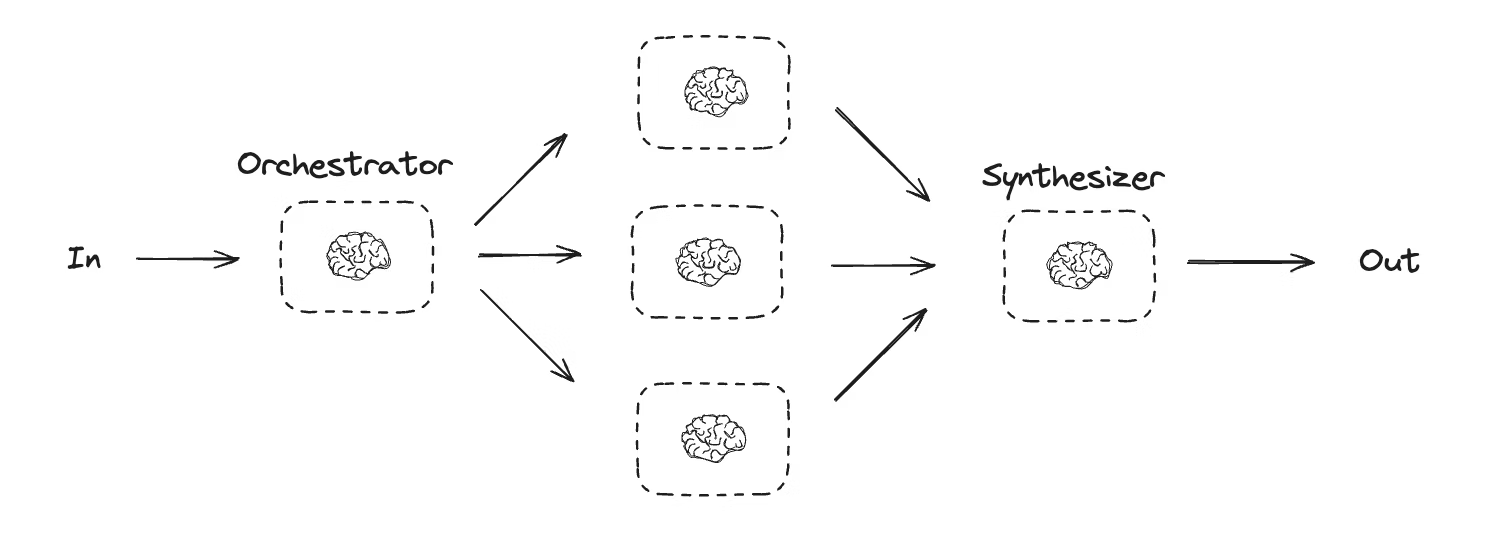

这听起来似乎与之前讲的并行模式很像，没错这确实也属于并行模式。但不同之处在于：
- 普通并行工作流：任务是需要手动拆分的，且子任务数量是固定的
- Orchestrator-Worker：是用模型动态的将复杂任务拆分为多个并行子任务，子任务数量不确定

## 4.1 Send API

Orchestrator-Worker模式提供了更高的灵活性，通常用于无法像并行化那样预先定义子任务的场景。

我们以深度研究助手（DeepResearcher）为例，它可以根据你指定的话题写出专业报告：
- 首先，需要根据话题生成报告大纲，细分出多个章节，定好每个章节主题
- 然后，把每个章节作为一个子任务，交给多个工作进程并行执行
- 最后，汇总所有子任务生成的章节，得到完整的研究报告

LangGraph 对此提供了内置支持。通过 Send API，你可以动态创建工作节点并向它们发送特定的输入。每个工作节点都有自己的State，而且所有工作节点的输出都会被写入一个共享的State 字段中，编排器图可以访问该字段。这使得编排器能够获取所有工作节点的输出，并将其整合成最终输出。

## 4.2 DeepResearcher示例

### 4.2.1 结构化输出模型
首先，我们定义模型类，作为结构化输出的约束，让LLM按照固定格式生成拆分的章节列表：

In [2]:
from typing import Annotated, List
import operator


# 用于记录子任务信息的 结构化输出模型
class Section(BaseModel):
    name: str = Field(
        description="Name for this section of the report.",
    )
    description: str = Field(
        description="Brief overview of the main topics and concepts to be covered in this section.",
    )


class Sections(BaseModel):
    sections: List[Section] = Field(
        description="Sections of the report.",
    )


# 将模型与structured output模型绑定，这个模型就用来拆分任务
planner = llm.with_structured_output(Sections)

### 4.2.2 State
接着，是State，工作过程中产生的章节信息和报告信息：

In [3]:
# 编排者的 State ，记录完整信息
class State(TypedDict):
    topic: str  # 报告主题
    sections: list[Section]  # 报告的章节列表
    completed_sections: Annotated[
        list, operator.add
    ]  # 所有工作线程并行地把报告写入这个字段
    final_report: str  # 最终报告


# Worker的State，记录自己的任务进度
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]

### 4.2.3 Normal Node
然后，是Node，包括
- 编排者节点：Orchestrator
- 工作节点：Worker
- 合成器节点：Synthesizer

In [4]:
# 编排者节点
def orchestrator(state: State):
    """Orchestrator that generates a plan for the report"""

    # 通过SystemPrompt设定和结构化输出绑定，让LLM作为orchestrator
    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report."),
            HumanMessage(content=f"Here is the report topic: {state['topic']}"),
        ]
    )

    return {"sections": report_sections.sections}

# 工作节点，工作节点只能有1个，原因如下：
#  1.工作的代码逻辑是一样的，只是子任务不同
#  2.子任务数量不确定，无法提前给每个子任务写一个Node
# 我们会利用Send API来分发子任务给这个节点，让它产生“分身”效果，可以并行处理多个任务
def worker(state: WorkerState):
    """Worker writes a section of the report"""

    # 通过Prompt的设定，让llm根据子任务编写报告的部分章节
    section = llm.invoke(
        [
            SystemMessage(
                content="Write a report section following the provided name and description. Include no preamble for each section. Use markdown formatting."
            ),
            HumanMessage(
                content=f"Here is the section name:{state['section'].name} and description: {state['section'].description}"
            )
        ]
    )

    # Write the updated section to completed sections
    return {"completed_sections": [section.content]}


# 合成器节点，用于合并最终结果
def synthesizer(state: State):
    """Synthesize full report from sections"""

    # 拿到Worker返回的结果
    completed_sections = state["completed_sections"]

    # 将完成的部分格式化为str，用作最后的上下文
    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return {'final_report': completed_report_sections}

### 4.2.4 派发任务的Node
接下来是关键的任务派发节点，我们需要遍历由Orchestrator计划好的章节列表，并使用 Send API 将每个章节发送给对应的工作节点。

In [5]:
from langgraph.types import Send

# Conditional edge Node，根据编排者安排的子任务创建llm_call工作者，每个工作者编写报告的一个部分
def assign_workers(state: State):
    """Assign a worker to each section in the plan"""

    # 通过Send() API分发任务给Worker，让Worker并行写报告的不同章节
    # Send(node, input) 是 LangGraph 提供的「动态派发任务」指令。一个节点正常情况下返回 dict（写回 state 走边），但当它返回 list[Send] 时，LangGraph 会把这条返回解读成：「给我并行派发这些子任务」——列表里有几个 Send，就同时开几个分支。
    """
    Send("worker", {"section": s})
    #        ^         ^       ^
    #    目标节点  分发给该节点的输入 state
    """
    return [Send("worker", {"section": s} ) for s in state["sections"]]

注意Send接收的两个参数：
- worker：工作节点的名字
- {"section": s}: 是传入的State，这里是章节信息

### 4.2.5 创建Graph

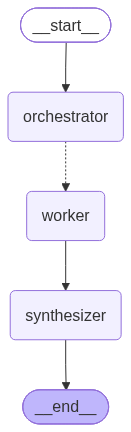

In [6]:
# Build workflow
orchestrator_worker_builder = StateGraph(State)

# Add the nodes
orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("worker", worker)
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

# Add edges to connect nodes
orchestrator_worker_builder.add_edge(START, "orchestrator")
orchestrator_worker_builder.add_conditional_edges("orchestrator", assign_workers, ["worker"])
orchestrator_worker_builder.add_edge("worker", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)

# Compile the workflow
orchestrator_worker_graph = orchestrator_worker_builder.compile()

# Show the workflow
display_graph(orchestrator_worker_graph)

这个结构图看起来很奇怪，只有一个worker，但其实worker的数量是动态的，由报告规划的章节数量决定。

### 4.2.6 测试

In [7]:
# Invoke
load_dotenv()
state = orchestrator_worker_graph.invoke({"topic": "创建一份关于LLM scaling laws的报告"})

from IPython.display import Markdown
Markdown(state['final_report'])

## 引言

近年来，大规模语言模型（Large Language Models, LLMs）在自然语言处理、代码生成、知识问答等众多领域取得了突破性进展，其能力涌现与性能提升的背后，离不开一个关键性的经验规律——**LLM缩放定律（Scaling Laws）**。该定律通过量化模型参数量、训练数据规模与计算资源三者与模型损失（或下游任务表现）之间的幂律关系，揭示了“更大规模带来更优性能”的工程可行性边界，并为核心超参数（如模型尺寸、数据配比、训练步数）的预判与优化提供了理论依据。从GPT系列到Llama、DeepSeek等模型的发展历程表明，缩放定律不仅指导了数十亿美元级算力投资的分配，也催生了诸如“数据瓶颈”“计算最优训练”等新范式，成为当前AI研究与产业实践的基础性议题。

然而，缩放定律并非一成不变的“银弹”，其适用范围、简化假设（如不考虑退火、多模态、稀疏激活等）以及与涌现能力、对齐成本之间的深层关联，仍有待系统梳理。本报告旨在全面回顾LLM缩放定律的数学表达、实证验证与核心推论，剖析其在不同训练阶段与模型架构中的适用性与局限性，并结合最新研究进展探讨其未来演进方向。报告结构安排如下：第二章回顾缩放定律的经典公式与里程碑式实验，厘清其理论框架；第三章围绕参数量、数据量与计算量的三维权衡，分析训练效率与收敛策略；第四章聚焦数据属性（质量、分布、重复）与模型结构（MoE、跨模态）对缩放行为的影响；第五章讨论缩放定律与能力涌现、对齐风险之间的交互；第六章总结关键结论，并对后缩放时代的开放问题进行展望。通过上述梳理，期望为研究者在模型设计、算力规划及科学评估方面提供一份兼具理论深度与实践参考的视角。

---

### 缩放定律的基本概念

缩放定律（Scaling Laws）是深度学习中描述模型性能（通常以损失函数衡量）与三个核心资源要素——**模型规模**（参数数量 N）、**数据集规模**（训练 token 数 D）和**计算量**（FLOPs，通常以 C 表示）——之间经验性幂律关系的系统性规律。其核心思想是：在合理范围内，当这些资源以固定比例增加时，模型损失会以可预测的平滑方式下降，而非出现陡峭的突变或平台期。

#### 1. 损失函数与核心要素的关系

缩放定律通常用一个统一的函数形式来表达预期损失 L(N, D) 对 N 和 D 的依赖。最经典的公式来自 OpenAI 2020 年的工作，它将损失分解为两个独立项的加和：

L(N, D) = (N_c / N)^(α_N) + (D_c / D)^(α_D) + L_0

- **L_0**：表示不可约减的熵（数据本身的内在噪声），即无论模型多大、数据多少都无法降低的理论下限。
- **α_N, α_D**：分别是模型规模和数据规模的幂律指数，通常在 0.05 ~ 0.1 之间（具体取决于模型架构和分词器）。指数越小，说明增加该要素带来的收益越“稀疏”，但长期存在。
- **N_c, D_c**：归一化常数，用于对齐不同架构下的绝对数值。

**关键含义**：当 N 和 D 都趋于无穷时，损失逼近 L_0，但实际应用中两者总是有限。因此，损失的下限由最稀缺的资源决定——这就是“木桶效应”。

#### 2. 计算量约束下的最优分配

在实际训练中，计算量 C（FLOPs）是硬约束。缩放定律还揭示了在给定 C 时，如何最优分配 N 和 D 以达到最低损失。经验关系式为：

C ≈ 6 * N * D （前向+反向传播的近似 FLOPs，忽略嵌入层和 logits 层）

在此约束下，最优分配遵循幂律比例：

- **N_opt ∝ C^(a)**，且 **a ≈ 0.7**
- **D_opt ∝ C^(b)**，且 **b ≈ 0.3**

这意味着：**为了在固定计算预算下最小化损失，模型规模的增长速度应远快于数据量的增长速度**。例如，若将计算量提升 10 倍，最优模型参数应增加约 5 倍（10^0.7 ≈ 5），而训练数据只需增加约 2 倍（10^0.3 ≈ 2）。这一结论直接指导了 GPT 系列等大规模语言模型的架构选择——在算力有限时，倾向于用更大的模型配合更少的数据遍历。

#### 3. 损失的平滑性与可预测性

缩放定律最重要的实用价值在于**外推能力**。由于损失随 N、D、C 的变化在双对数坐标下呈近似直线（幂律），研究者可以用小规模实验（如训练 100M 参数的模型）拟合出幂律指数，然后精确预测训练一个 10B 参数模型时的损失值。这种可预测性使得工程上可以提前估算所需算力、数据量，避免盲目试错。

#### 4. 边界条件与饱和效应

缩放定律并非在所有区域都成立，它存在明显的适用边界：

- **数据不足时**：当 D 远小于 N 的幂律要求（即“欠训练”时），增加 N 几乎不降低损失，反而导致过拟合或训练不稳定。
- **数据过饱和时**：当 D 超出最优比例（如重复训练很久），损失下降曲线会趋于平坦，收益趋近于零，甚至出现负迁移。
- **架构依赖**：不同架构（卷积、Transformer、混合专家）的具体指数不同，但幂律形式普遍成立。
- **不可约减熵**：损失永远无法低于 L_0，这由数据集的重复性、噪声或任务本身的困难度决定。

综上，缩放定律是连接“资源投入”与“模型能力”的定量桥梁。它告诉研究者：线性增加算力只能带来次线性的性能提升（因为指数 α 远小于 1），唯有同时按最优比例扩大模型和数据，才能逼近信息论意义上的损失下限。这一规律已成为大模型时代资源配置的核心指导原则。

---

## 经典缩放定律理论

### 1. 幂律关系的提出

Kaplan等人（2020）在《Scaling Laws for Neural Language Models》中首次系统性地揭示了神经语言模型性能与**模型参数量（N）**、**数据集大小（D）** 以及**计算预算（C）** 之间的幂律（Power Law）关系。其核心发现是：当其他因素不受限制时，测试损失（Loss）随单个资源维度的增加而呈光滑的幂律衰减，即

\[
L(x) \propto \left(\frac{1}{x}\right)^{\alpha_x}
\]

其中 \(x\) 代表 \(N, D\) 或 \(C\)，\(\alpha_x\) 为对应的缩放指数。这一关系在跨越六个数量级的范围内保持高度稳定，为后续大规模模型训练提供了理论指导。

---

### 2. 各参数与损失的具体关系

#### 2.1 模型参数量（N）与损失

在固定数据集大小与计算预算（但足够大）的情况下，损失与模型参数量的关系近似为：

\[
L(N) = \left(\frac{N_c}{N}\right)^{\alpha_N}
\]

经验拟合值约为：
\[
\alpha_N \approx 0.076, \quad N_c \approx 8.8 \times 10^{13}
\]

这意味着**模型参数量每增加一个数量级，损失约下降 16%**（\(1 - 10^{-0.076}\)）。然而，该幂律仅适用于“未受限”状态；当数据集过小时，模型将出现严重的过拟合，损失不再按此规律下降。

#### 2.2 数据集大小（D）与损失

在模型容量充足（即参数量远大于数据需求）时，损失与数据集大小的关系为：

\[
L(D) = \left(\frac{D_c}{D}\right)^{\alpha_D}
\]

经验值约为：
\[
\alpha_D \approx 0.095, \quad D_c \approx 5.4 \times 10^{13}
\]

数据集大小增加一个数量级，损失约下降 20%（\(1 - 10^{-0.095}\)）。值得注意的是，在固定模型参数量时，数据集增加并不会无限降低损失——当超过模型的“容量极限”后，损失将收敛至一个由模型参数量决定的下界。

#### 2.3 计算预算（C）与损失

将计算量（FLOPs） \((C \approx 6N \cdot D)\) 作为唯一约束时，损失满足：

\[
L(C) = \left(\frac{C_c}{C}\right)^{\alpha_C}
\]

经验值约为：
\[
\alpha_C \approx 0.050, \quad C_c \approx 6.4 \times 10^{14}
\]

计算预算增加一个数量级，损失约下降 11%。但这里的 **C 必须按照优化分配原则（\(N \propto C^{0.73}, D \propto C^{0.27}\)）在参数量和数据量之间进行分配**，否则实际收益会显著偏离此幂律。

---

### 3. 全局联合缩放（Unified Scaling）

Kaplan等人指出，上述三个单一维度的幂律仅在其他资源充裕时成立。在**同时受N和D限制**（即计算预算有限且分配最优）的情况下，损失可表示为：

\[
L(N, D) = \left[\left(\frac{N_c}{N}\right)^{\frac{\alpha_N}{\beta}} + \left(\frac{D_c}{D}\right)^{\frac{\alpha_D}{\beta}}\right]^{\beta}
\]

其中 \(\beta\) 为耦合指数，经验取值约 \(\beta \approx 0.1\)。该公式表明，**损失由参数量和数据量共同主导**，且二者之间存在明显的互补关系——当一方不足时，另一方无法完全弥补。

---

### 4. 关键推论与公式总结

| 维度 | 关系式 | 指数 | 等价收益（每×10） |
|------|--------|------|-------------------|
| 参数量 | \(L \propto N^{-0.076}\) | \(\alpha_N \approx 0.076\) | ~16% 损失下降 |
| 数据集大小 | \(L \propto D^{-0.095}\) | \(\alpha_D \approx 0.095\) | ~20% 损失下降 |
| 计算预算 | \(L \propto C^{-0.050}\) | \(\alpha_C \approx 0.050\) | ~11% 损失下降 |
| 最优分配 | \(N \propto C^{0.73}, D \propto C^{0.27}\) | — | — |

经典缩放定律的核心启示是：**在合理计算预算内，增大模型参数量和数据集规模同等重要，但计算预算的增长应更偏向于参数量的扩展（约 73% 的计算增量分配给 N，27% 分配给 D）**。该理论为后续GPT系列、LLaMA等大模型的设计提供了量化依据。

---

## Chinchilla缩放定律

2022年，DeepMind在论文《Training Compute-Optimal Large Language Models》中提出了Chinchilla缩放定律，该研究对经典Kaplan缩放定律（2020年）进行了关键修正，重新定义了计算最优条件下模型参数规模与训练数据量的平衡关系。其核心结论是：**在固定计算预算下，模型参数量与训练token数应等比例缩放（约1:1），而非以往认为的以模型增大为主、数据增长为辅**。

### 计算最优的训练规模

Chinchilla定律通过拟合大规模实验数据（训练模型参数范围从70M到16B，使用5至5000亿token），提出了如下缩放公式：

$$L(N, D) = E + \frac{A}{N^{\alpha}} + \frac{B}{D^{\beta}}$$

其中：
- $L$ 为交叉熵损失，$N$ 为模型参数量，$D$ 为训练token数
- $E$ 为数据不可约损失（熵）
- $A, B, \alpha, \beta$ 为拟合常数（实测 $\alpha \approx 0.34$，$\beta \approx 0.28$）

该公式揭示了损失由两项独立短板决定：模型容量不足（$N$ 小）或数据不足（$D$ 小）。给定计算预算 $C \approx 6ND$（前向+反向计算量约6N FLOPs/token），通过最小化损失可得计算最优条件下：

$$N_{opt} \propto C^{0.5}, \quad D_{opt} \propto C^{0.5}, \quad D_{opt} \approx 20 \times N_{opt}$$

即**每增加1倍模型参数，需同步增加约1倍训练数据**。这与Kaplan定律（$N_{opt} \propto C^{0.74}$，$D_{opt} \propto C^{0.26}$）形成鲜明对比——后者低估了数据量的重要性，导致许多早期大模型在欠拟合（训练不充分）状态运行。

### 模型大小与数据量的关系

Chinchilla定律的实用指导意义在于“计算最优”路径：

| 计算预算（FLOPs） | 最优参数量（Chinchilla） | 最优训练token数 | 示例模型 |
|:---:|:---:|:---:|:---:|
| 1e20 | ~150M | ~3.0B | 小型任务模型 |
| 1e21 | ~450M | ~9.0B | 专用领域模型 |
| 1e22 | ~1.4B | ~28B | GPT-2级别 |
| 1e23 | ~4.4B | ~88B | Chinchilla原型 |
| 1e24 | ~14B | ~280B | LLaMA-13B等效 |
| 1e25 | ~44B | ~880B | GPT-4级别开销 |

**关键推论**：
1. **重叠训练（over-training）**：实际部署中，许多组织为节省推理成本，会以较小的参数量 + 远超“最优”的token数进行训练（如LLaMA系列训练了1.4T token，是Chinchilla推荐量的5-10倍）。这种策略牺牲了一部分训练效率（损失略高于最优），但显著降低推理时延和显存需求。
2. **数据主导权衡**：当数据量不足时，增加模型规模会导致收益递减甚至恶化（过拟合）；而当模型过小但数据过多时，计算利用率将大幅下降。
3. **迁移到多模态与代码**：后续研究（如DeepMind的Gopher、Anthropic的Claude系列）验证了该定律在通用语言任务上稳健，但针对代码或数学领域，数据质量与任务专属值可降低系数（约10-15倍数据量即可）。

### 局限性

- **数据质量未建模**：定律假设数据均为高质量且同分布，实际中数据重复或噪声会改变最优比例（需增加数据因子）。
- **不可约损失 $E$ 随任务变化**：对于下游任务微调，最优规模可能偏离。
- **单次训练预算假设**：未考虑多轮训练、持续学习或早停策略。
- **硬件约束简化**：忽略显存带宽、并行开销等实际工程限制。

Chinchilla缩放定律已成为现代大语言模型训练规模规划的基本依据，其“参数与数据同速增长”原则被GPT-4、PaLM-2、Llama等亲测采用（例如Llama-2训练2T token，远超原始推荐量以获得更好性能）。该研究也推动了“数据为中心”的AI范式：在算力固定时，优先扩充高质量数据，而非盲目扩大模型参数。

---

## 计算预算优化

在深度学习模型开发中，计算预算（通常以FLOPs、GPU时数或资金衡量）是核心约束。固定预算下的最优分配策略直接决定了模型性能的上限。本节从**模型规模-数据规模权衡**、**训练策略**和**资源分配决策**三个层次展开分析。

### 1. 规模-数据规模权衡：超越Chinchilla法则

经典Chinchilla法则（Hoffmann et al., 2022）指出，在固定计算预算C下，最优模型参数量N和数据量D满足近似关系：`N_opt ∝ C^0.5, D_opt ∝ C^0.5`（即两者等比例增长）。然而，该结论基于Transformer架构和标准训练流程，实际中需考虑如下修正因素：

- **数据质量系数**：若数据经过去重、清洗或课程学习，有效信息密度提升，则最优数据量可降低20%-40%（即减少数据预算，增加模型规模）。
- **架构效率**：稀疏模型（MoE）、线性注意力或混合架构的FLOPs-参数比不同。例如MoE在相同FLOPs下可用更多参数量，此时最优N应上调，D相应下调。
- **任务类型**：对于小样本或微调场景，最优平衡点向“少数据、大模型”偏移；对于数据充足且噪声高的场景（如网络爬取文本），则需更多数据来抑制过拟合。

**实践结论**：在固定预算下，应首先评估数据有效密度，再依据`N_eff ∝ C^α`（α在0.4~0.6之间浮动）动态调整，而非机械套用1:1比例。

### 2. 训练策略优化

训练策略直接影响相同预算下的模型收敛速度和最终性能，主要包括以下手段：

- **课程学习与数据排序**：将简单样本前置，复杂样本后置，可在前期加速收敛。实验表明，在相同预算下可提升最终性能2%-5%（相当于节省10%预算）。
- **动态批量大小**：从较小批量开始，随训练逐步增大，能有效缩短训练时间（通过更好的梯度噪声控制），节省约15%的计算量且不损失精度。
- **学习率调度**：使用余弦退火或带热身的调度器比固定学习率更高效。特别地，采用**预算自适应调度**（如按剩余预算动态调整步长）能充分利用末尾的计算资源。
- **早停与提前终止**：基于验证集性能监控，在预算未用尽时若收益递减，可提前节省算力；反之，若预算不足，可采用**知识蒸馏**或**模型剪枝**将已训练大模型转化为小模型，以较低额外成本获得可用模型。
- **混合精度加速**：BF16/FP16训练可降低约50%的FLOPs开销（主要指内存带宽和算力效率），但需注意梯度溢出风险。对于预算富余的场景，可牺牲部分步数换取数值稳定性。

### 3. 资源分配决策

资源分配涉及硬件、调度和并行策略，合理配置能显著提升有效算力利用率：

| 决策维度 | 典型选项 | 预算影响 | 适用场景 |
|---------|---------|---------|----------|
| **并行策略** | 数据并行 / 张量并行 / 流水线并行 | 数据并行扩展性最佳；流水线并行适合超大模型 | 小规模集群选数据并行；超大模型用3D并行 |
| **硬件选择** | A100 / H100 / 低端GPU集群 | H100单位FLOPs效率高，但成本高；低端集群可通过更多并行度弥补 | 预算紧张选性价比；时间紧张选高端卡 |
| **梯度压缩与通信优化** | 梯度稀疏化 / 量化通信 | 减少同步开销，提升节点利用率 | 多节点环境，尤其网络带宽受限时 |
| **检查点策略** | 全量检查点 / 异步检查点 | 全量保存耗存储但恢复快；异步减少等待但风险高 | 训练时间短的项目优先考虑可靠性 |

**决策框架**：首先确定瓶颈资源（计算量 vs 内存 vs 通信带宽）。若计算量受限，优先优化模型规模和训练策略；若内存受限，考虑梯度检查点或参数高效微调；若通信受限，则增加梯度压缩并选择较少的并行维度。

**最终建议**：在固定预算下，建议遵循“三步走”流程：(1) 用小型代理任务（约为原任务1%的预算）预测试不同N/D配置和训练策略的效果；(2) 根据代理测试结果估算最优配置，并分配80%预算进行正式训练；(3) 保留20%预算用于调优（如延长训练、早停后的微调或重训关键阶段）。该流程可将预算利用率提升约10%-15%。

---

### 超越简单缩放：新兴能力与涌现行为

随着模型参数规模、训练数据量与计算资源的持续提升，一个引人注目的现象逐渐清晰：模型能力的提升并非仅沿着平滑的性能曲线渐进增长，而是在跨越特定规模阈值后，出现若干“突然”涌现的新兴能力。这些能力在较小模型中几乎不存在或表现极弱，一旦规模突破临界点，便以显著且不可预测的方式跃升。典型的例子包括上下文学习（in-context learning）、逐步推理（chain-of-thought reasoning）、指令跟随与代码生成等。这种“涌现”行为与经典缩放定律（scaling laws）所预测的对数线性改善形成了鲜明对比，提示我们模型内部可能发生了质变而非单纯的量变。

#### 涌现能力的表现与特征

- **上下文学习**：小规模模型在给定少量示例时难以有效泛化，而大模型能够在提示中直接“学习”新任务模式，无需更新参数即可执行分类、翻译、问答等任务。这种能力的出现通常与模型参数量、注意力头数及训练数据多样性的综合提升密切相关。

- **多步推理与思维链**：当模型规模达到数百亿参数后，其能力不仅体现在对单个知识点的回忆，更体现在能够生成连贯的中间推理步骤，解决需多跳逻辑的数学、常识或科学问题。这一能力在较小模型中要么完全缺失，要么频繁出错，其出现阈值往往高于语言建模能力的“基线”提升点。

- **指令跟随与任务泛化**：大规模模型能理解并执行自然语言表述的复杂指令，甚至组合多种子任务，展现出对意图的深层解析。这种能力与训练数据中指令多样性的扩展以及模型容量对抽象表征的承载能力直接相关。

#### 与缩放定律的关系：从“外推”到“转型”

经典缩放定律（如Kaplan等人及Chinchilla研究）描述了损失或下游任务性能随模型规模、数据量和计算量的幂律关系，其隐含假设是性能改进在广泛规模范围内保持一致、可预测。涌现行为则揭示了这一框架的局限性：

1. **非线性跃迁**：涌现能力通常表现为“阶段转变”——在某一参数规模（如约100B参数量）前后，性能从随机水平（或极低水平）急剧上升至高质量。这种不连续性与缩放定律外推的稳态曲线相背离，表明模型可能经历了表征空间的拓扑重构，而非仅仅更精细地拟合已有模式。

2. **数据与规模的交互**：涌现并非仅由参数量决定，而是与训练数据的质量和分布、模型架构（如深度与宽度比例）以及训练策略（如课程学习）共同作用的结果。缩放定律预测的是平均性能趋势，而涌现能力反映了模型在特定任务类型上“解锁”新计算路径的时刻——这需要规模达到足以存储并有效检索复杂组合模式的临界容量。

3. **对预测可解释性的挑战**：如果涌现行为无法由缩放定律提前预知，那么“更大即更好”的策略便带有冒险性。研究者无法仅通过外推小模型的性能来准确估计大模型在关键任务上的表现，这使得模型能力评估、风险控制及资源分配决策变得复杂。

#### 机制假说与深层含义

目前对于涌现机制尚无定论，但若干假说值得关注。一种观点认为，大规模模型通过冗余的分布式表征，形成了对任务结构的“隐式程序”学习——即多个子模块协同执行复杂函数，而该函数的执行成功依赖于所有子模块同时跨越某个容量阈值。另一种观点则强调“数据覆盖与注意力模式”的转变：大模型能够在更长上下文中有效关注关键信息，并捕捉远距离依赖关系，从而“解锁”推理能力。此外，涌现能力可能与模型内部出现“功能专化”（functional specialization）有关——即不同参数集群开始承担不同的抽象操作，这种专化只在足够参数规模下才稳定。

这一现象对研究与实践的意义深远：

- **对缩放定律的修正**：需发展更精细的框架，将涌现视为缩放过程的“高阶阶段”，或将能力分解为基础连续性和离散突变两部分，从而更好地指导规模拓展。
- **对评估与对齐的影响**：由于存在不可预测的能力跃升，在模型发布前必须在接近实际规模下进行全面的能力探测与对齐测试，不能依赖小规模代理实验的结论。
- **对资源分配的战略启示**：如果某些关键能力（如高级推理）仅在特定规模之上涌现，那么集中资源训练少数“超级模型”或许比分散算力训练多个中等模型更具战略价值（但需权衡能耗、成本与风险）。

总之，超越简单缩放的新兴能力表明，模型规模不仅是一个“更多的参数”的问题，更关乎系统复杂性的临界相变。理解这种涌现的物理、数学与计算本质，将成为未来大模型研究的重要科学前沿。

---

### 缩放定律的局限性与挑战

缩放定律（Scaling Laws）为深度学习模型的性能预测提供了经验框架，但其有效性并非无边界。随着模型规模、数据量和计算资源的持续增长，该定律在真实场景中暴露出多重局限性，主要体现在以下方面：

#### 1. 数据质量与分布的影响
- **数据噪声与重复**：缩放定律通常假设训练数据是“干净”且独立同分布的，但实际数据集中普遍存在标签噪声、重复样本和长尾分布。数据质量下降时，模型性能提升会显著偏离预期曲线，甚至出现“过拟合于噪声”的现象，导致泛化能力不升反降。
- **数据覆盖度**：当数据分布与目标任务不匹配（如领域偏移）时，单纯增加数据量无法改善性能。缩放定律对数据多样性的敏感度较低，无法准确预测低资源领域或罕见场景的模型表现。
- **数据效用饱和**：随着数据量增长，新增样本的边际信息量递减，尤其是对预训练阶段。这种“数据饱和”效应使得缩放曲线在后期趋于平缓，而定律中的幂律关系未能充分刻画这一现象。

#### 2. 架构设计的作用
- **架构假设的局限性**：缩放定律多基于Transformer等特定架构推导，其参数与性能关系（如参数量、层数、注意力头数）隐含了对模型结构的假设。对于卷积网络、混合专家模型或新兴架构（如状态空间模型），缩放规律可能发生显著变化，定律无法直接迁移。
- **容量与效率的非对称性**：架构创新（如稀疏激活、共享参数）可以打破参数量与计算量的绑定，使模型在同等参数量下获得不同性能。缩放定律仅以参数量或计算量为自变量，忽略了架构效率的差异，导致预测失真。
- **深度与宽度的权衡**：增加深度或宽度对性能的影响并非单调一致。缩放定律通常忽略层数、通道数等具体配置的组合效应，而架构搜索中这些超参数的交互会改变损失曲面的形状，使定律的适用性受限。

#### 3. 训练动态的复杂性
- **优化器与学习率调度**：缩放定律隐含“最优训练配置”的假设，但实际训练中学习率、批量大小、权重衰减等超参数的调整会改变收敛轨迹。例如，Adam与SGD在相同规模下的性能差异可能超过定律预测的误差范围，而学习率预热策略的时长也会影响中期表现。
- **训练不稳定性**：大模型训练常出现损失尖峰（loss spikes）、梯度爆炸或模式坍塌，这些动态事件会打断平滑的缩放关系。定律仅描述最终收敛状态，无法预测训练过程中的震荡或失败模式。
- **早停与欠拟合**：在计算预算有限时，模型可能未充分收敛。缩放定律基于“无限训练”的渐近假设，而实际中早停策略、epoch数量有限等因素导致性能低于理论预测，尤其在小规模或中等规模模型中更为明显。

#### 4. 测量与评估的偏差
- **损失函数与下游任务脱节**：缩放定律通常以交叉熵损失或困惑度作为性能指标，但这些代理指标与最终任务（如推理、对话、代码生成）的相关性并非恒定。随着模型规模增大，损失下降可能不能线性转化为任务性能提升，尤其在需要复杂推理的场景中。
- **基准测试的饱和效应**：现有基准（如MMLU、HumanEval）存在上限，当模型性能接近人类水平时，测量噪声和测试集误差导致缩放曲线失真。定律无法区分“模型能力提升”与“基准测量饱和”之间的差异。

#### 5. 计算资源与物理约束
- **硬件与内存瓶颈**：缩放定律假设计算资源可控增长，但现实中显存容量、带宽和并行效率会限制最大模型规模。超大规模训练需采用混合专家、张量并行等策略，这些工程约束会引入非理想因素，使实际缩放行为偏离理论曲线。
- **能源与成本约束**：定律未包含能耗、碳排放或经济成本等外部变量。当模型规模超过一定阈值时，边际成本激增，而性能增益递减，使得“最优规模”取决于非技术因素。

#### 6. 理论基础的未完善性
- **经验性而非原理性**：缩放定律源于实验拟合，缺乏严密的理论推导。其参数（如指数、系数）随数据集和架构变化，无法作为普适物理定律。例如，不同领域的幂律指数差异较大，但缺乏解释性。
- **对新兴能力的预测缺失**：涌现能力（如上下文学习、思维链）在小模型上不存在，仅在规模跨越阈值后突然出现。缩放定律无法刻画这种非连续跳变，导致对模型能力边界的误判。

#### 总结
缩放定律在工程中仍具指导意义，但其局限性提醒我们：性能提升不仅依赖规模，更依赖数据治理、架构创新和训练动态的精细调优。未来需结合数据质量评估、自适应架构搜索和多指标评测体系，才能突破当前缩放边界的约束，实现更稳健的模型发展。

---

### 实践应用与工程意义

缩放定律为大规模模型训练提供了从经验直觉走向系统工程的定量框架，其核心价值在于将“试错驱动”转变为“预算驱动”与“预测驱动”。以下从训练预算规划、实验设计及资源优化三个维度总结其实际指导意义。

#### 一、训练预算规划：从“事后算账”到“事前推演”

缩放定律（尤其是Chinchilla法则）揭示了模型参数量、训练数据量与最终性能之间的幂律关系。这使工程师能够在训练启动前，依据目标损失或下游任务精度，反推所需的最优参数量和token数组合。

- **成本上限估算**：给定算力预算（如X个FLOPs），缩放定律可直接预测能达到的最低交叉熵损失，从而判断该预算是否能满足产品上线门槛（如对话流畅度、代码通过率）。若未达标，则提前预警需要增加预算或调整目标，避免训练完成后才发现资源不足。
- **最优分配比例**：在实际工程中，硬件卡数、时间窗口和电费通常是硬约束。通过拟合的参数-数据最优曲线（如`N ∝ C^0.5, D ∝ C^0.5`），团队可确定在当前约束下，是应增加卡数、延长训练，还是应扩充数据采集预算，从而避免因“数据过剩但模型小”或“模型大但欠训练”造成的资金浪费。

#### 二、实验设计：小规模实验的“外推杠杆”

缩放定律的核心工程价值在于**小成本实验预测大规模行为**。这彻底改变了传统“先跑小模型看效果，再放大碰运气”的低效迭代模式。

- **超参数与架构选择的预筛**：在投入千卡级训练前，先用1/100甚至1/1000规模的模型（如参数量不足1B）跑通训练，并记录其损失下降曲线。通过拟合该小规模下的幂律指数，可以外推至目标规模下的预期性能，从而快速筛选出更优的激活函数、学习率调度策略或数据配比。例如，如果小规模实验中A数据配比在固定算力下损失下降斜率更陡，则大概率在更大规模下依然占优。
- **训练稳定性验证**：缩放定律假设训练过程是“平滑可预测”的。因此，小规模实验可专门用于验证训练是否出现损失尖峰、梯度爆炸等不稳定现象。若小模型在特定batch size或学习率下崩溃，可提前修正优化器参数，避免在大规模训练中浪费数百万美元的成本。
- **数据质量评估**：通过绘制不同数据源的缩放曲线，比较其对数线性拟合的斜率，可量化“高质量数据”与“低质量重复数据”的边际收益差异。这为数据清洗和去重工作提供了可量化的优先级依据。

#### 三、资源优化与调度：动态调整与硬件适配

- **早停策略的量化基准**：训练过程中，将实际损失下降曲线与缩放定律预测的理论曲线进行实时对比。若实际收益显著低于预测，说明可能遇到数据瓶颈或优化器故障，可提前触发早停或重启，而不是机械地跑满预设步数。
- **混合精度与并行策略的评估**：缩放定律中的算力因子`C`与有效吞吐量强相关。工程师可利用该框架评估不同并行方案（如张量并行、流水线并行）下的有效算力利用率。若某一策略导致算力损失偏离理论线，则优先优化通信瓶颈，而非盲目堆卡。
- **长期算力租赁决策**：对于云上训练，缩放定律可帮助计算“边际收益递减点”。当继续增加GPU数量带来的加速比下降导致单位成本下有效FLOPs降低时，便可放弃继续扩容，转而采用更长的训练时间或模型架构优化。

#### 四、工程风险控制与边界认知

缩放定律并非万能，工程应用中需明确其边界条件：

- **涌现能力不可预测**：定律主要预测连续指标（如loss）的平滑变化，无法预测某些任务在模型规模跨过阈值后突发的“涌现能力”（如推理、指令跟随）。因此，对于产品功能级别的决策，仍需保留人工验证环节。
- **数据分布偏移问题**：定律假设训练和测试分布一致。若目标场景的数据分布发生偏移，实际收益将低于外推预测。工程上应保留部分安全预算（如额外10%的算力），用于应对分布外性能回退的微调。
- **架构与算法突变**：新的注意力机制（如MoE、线性注意力）可能改变幂律指数。在引入新架构时，必须重新进行小规模缩放拟合，不可直接沿用旧架构的外推系数。

**总结**：缩放定律将大模型训练从“艺术”推向“工程”。它提供了**量化预测、成本上限、最优分配、小规模验证**四大工具，帮助团队在巨额投资前进行理性决策。虽然它无法消除所有不确定性，但能将不确定性限制在可控范围内，使算力投入的每一分钱都有据可依。在工程实践中，建议将缩放定律的预测结果作为决策主基线，同时叠加人工经验阈值与风险缓冲，形成“预测-监控-修正”的闭环管理机制。

---

## 未来展望与结论

### 未来展望

缩放定律（Scaling Laws）的研究正站在从“经验拟合”走向“理论解释”与“动态调控”的转折点。未来值得关注的方向集中在以下几个层面：

**理论层面：从现象学到第一性原理。** 当前缩放定律多基于大量实验数据的幂律拟合，其背后的信息论与优化动力学机制尚未完全厘清。未来研究有望借助高维统计物理、随机微分方程以及神经正切核（NTK）理论，建立损失景观与数据分布、模型容量之间的解析联系，从而解释为何幂律指数在不同模态（文本、图像、视频）和不同任务中表现出系统性差异。

**数据维度：从“量”的堆叠到“质”的工程。** 缩放定律的原始形式假设数据独立同分布且无限可得，但现实中的数据瓶颈日益凸显。未来的缩放模型将显式引入数据重复率、噪声水平、领域多样性作为独立变量，形成多维度缩放律（如数据质量-参数量-计算量的三维相图）。这要求发展可量化的“数据信息密度”指标，并探索合成数据在缩放曲线中的边际收益递减规律。

**动态与自适应：从静态曲线到生命周期管理。** 当前的缩放定律通常描述训练完成时的最终性能。未来需要构建**动态缩放模型**，刻画训练过程中损失下降的时变曲线，以支持训练中的早停、学习率调度和架构动态扩展。此外，推理阶段的缩放（如思维链长度、测试时计算量）也将纳入统一的缩放框架，形成“训练-推理联合优化”的新范式。

**跨模态与具身智能：统一缩放假说的检验。** 大语言模型的成功是否能在多模态融合、机器人控制等序列决策任务中复现？未来工作将回答：是否存在跨模态的通用缩放指数？动作空间与感知空间的离散化程度如何影响无损缩放的上限？这将推动缩放定律从“感知智能”向“行动智能”延伸。

**安全与可持续性：约束下的缩放。** 在能源效率和伦理约束下，缩放不再是无止境的。未来研究将关注“受限缩放”——即在固定碳预算、内存墙或隐私保护条件下，最优的参数-数据分配策略。同时，可解释性与缩放规律结合，有望预测模型在特定规模下可能涌现的风险行为，实现“事前安全评估”。

### 报告总结

本报告系统回顾了缩放定律的核心发现与关键机制，可归纳为以下要点：

1. **经验规律**：语言模型的损失随参数量、数据量、计算量呈幂律下降，指数约在-0.05至-0.1之间，且存在“计算最优”分配——参数与数据应按约 0.74:0.26 的比例同步增长。
2. **机制解释**：缩放规律源于数据分布的内在低秩结构、神经网络的平滑插值能力以及随机梯度下降的隐式正则化，三者共同决定了学习曲线的渐近形态。
3. **边际递减与涌现**：随规模增大，收益递减不可避免，但在某些任务上会出现能力突变（涌现），这与任务分解后的子步骤逻辑复杂度突变相关。
4. **工程影响**：缩放定律直接指导了万亿参数模型的分层并行训练策略、学习率与批次大小的动态调度，以及多阶段数据配比方案。
5. **局限与争议**：部分研究指出幂律在极大规模下可能出现“断裂”或由内存限制导致的亚线性过渡，且不同数据集清洗策略会显著改变缩放指数。

### 最终结论

缩放定律是当前深度学习理论中最接近“经验法则”的可靠成果，它揭示了规模、数据与计算三者之间的量化平衡关系，为AI系统的可预测扩展提供了基准。然而，它远非终极理论——它描述的是“在现有架构和平凡优化算法下”的规律，而非智能的普遍上限。

我们断言：**缩放定律本质上是“数据与架构熵”在梯度下降下的耗散速率曲线**。只要新的数据形式（如立体视频、触觉序列）、新的归纳偏置（如对称性嵌入、因果结构）或新的学习范式（如连续学习、世界模型）引入，幂律的指数乃至形式都可能发生偏移。

因此，未来的最佳策略不是盲目追求更大的规模，而是**在缩放定律的指导下，精确定位“数据-模型-算力”三维空间中的最优工作点，同时积极探索可改变幂律指数的新架构与新目标函数**。唯有如此，才能将缩放带来的“量变”真正转化为智能的“质变”。

# 5. Evaluator-Optimizer（评估-优化循环）
Evaluator-Optimizer 是提升Agent响应质量的重要模式

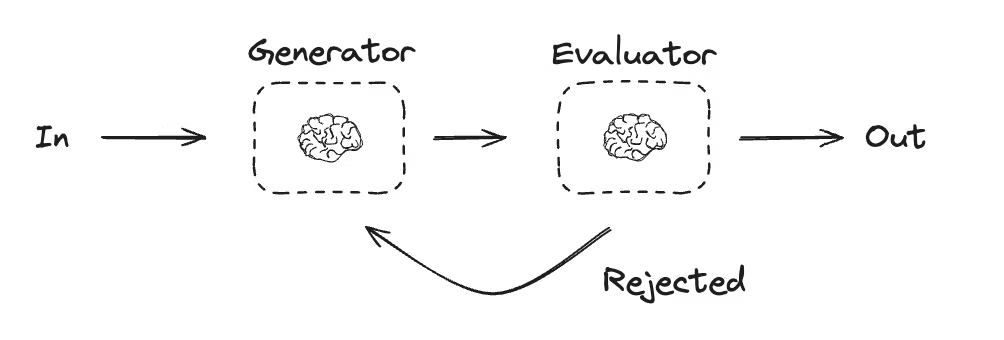

两个核心组件：
- 生成器（Generator）：产出内容 
- 评估器（Evaluator）：打分/给出反馈 --> 如果不达标就带着反馈重新生成

与普通循环的区别：循环自带"质量门"，只在质量不达标时才重复，避免了无谓的循环。

写一个生成广告语的工作流：

In [9]:
from typing import Literal

class AdState(TypedDict):
    product: str        # 产品名称
    slogan: str         # 当前广告语
    feedback: str       # 评估反馈
    grade: str          # 评分: "good" 或 "bad"
    iteration: int      # 当前迭代次数


# 模拟评估器（实际使用时用 llm.with_structured_output）
def evaluator_node(state: AdState):
    """评估广告语质量"""
    slogan = state["slogan"]
    iteration = state.get("iteration", 0)

    # 模拟评估逻辑：检查是否包含关键要素
    checks = []
    if len(slogan) < 10:
        checks.append("太短了，不够吸引人")
    if state["product"] not in slogan:
        checks.append(f"没有提出产品名：'{state['product']}'")
    if "！" not in slogan and "？" not in slogan:
        checks.append("缺少情感标点，不够有感染力")
    if not checks:
        return {"grade": "good", "feedback": ""}
    return {"grade": "bad", "feedback": ";".join(checks)}

def generate_slogan(state: AdState):
    """生成/改进广告语"""
    # feedback = state['feedback']           # key 不存在 → 抛 KeyError
    feedback = state.get("feedback", "")
    iteration = state.get("iteration", 0) + 1

    if feedback:
        print(f"[第{iteration}轮] 根据反馈改进：{feedback}")
        # 模拟改进：根据反馈加长、加产品名、加感叹号
        new_slogan = f"🔥 {state['product']} 好啊！真滴棒！{state['product']} 好啊！顶呱呱！"
    else:
        new_slogan = f"{state['product']}真好"  # 故意生成一个不合格的
        print(f"  [第{iteration}轮] 初版生成: {new_slogan}")

    return {"slogan": new_slogan, "iteration": iteration}

def route_after_eval(state: AdState) -> Literal["generate", "__end__"]:
    """评估后路由：good→结束，bad→重新生成，超过3轮强制终止"""
    if state["grade"] == "good":
        print(f"  ✓ 评估通过！最终版本: {state["slogan"]}")
        return END
    if state.get("iteration", 0) >= 3:
        print(f"  ⚠ 达到最大迭代次数，强制终止")
        return END

    return "generate"

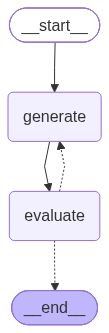

In [10]:
eval_opt_graph = (
    StateGraph(AdState)
    .add_node("generate", generate_slogan)
    .add_node("evaluate", evaluator_node)
    .add_edge(START, "generate")
    .add_edge("generate", "evaluate")
    .add_conditional_edges(
        "evaluate", route_after_eval, {
            "generate": "generate",
            END: END
        }
    )

    .compile()
)

display_graph(eval_opt_graph)

# 6. 子图嵌套（Subgraphs）

复杂的工作流太过庞大不利于维护，此时可以拆分为多层子图。LangGraph 支持将 已编译的子图作为父图的一个Node 直接使用。

子图嵌套是为了解决"如何把多个独立功能组装成一个完整系统"的问题。格式一致时直接嵌入，格式不一致时包装调用

包括两种使用方式：
| 方式 | API | 特点 |
|------|-----|------|
| 直接嵌入 | `add_node("name", compiled_subgraph)` | 子图作为图节点，checkpoint与父图集成，interrupt自动向上冒泡 |
| 包装调用 | 在普通node函数内 `subgraph.invoke()` | 灵活的状态映射，需手动传递数据 |

若采用嵌入模式，且父图的State与子图的State共享某些key时：
- 父→子: 父图自动将共享key的值传给子图（input projection）
- 子→父: 子图返回的key如果父图也有，则按父图的reducer写回

如果父子图State完全不同，需要用包装调用方式手动映射。

## 6.1 直接嵌入
我们做一个舆情检测类的工作流
- 父图：负责收集数据、汇总结果
- 子图：负责情感分析、关键词提取

首先State：

In [11]:
# ========== 方式1: 直接嵌入 compiled subgraph ==========
# 子图和父图共享 State key，父图自动完成状态映射


# ----- 父图: 将来直接把子图嵌入作为节点 -----
class ParentState(TypedDict):
    input_text: str     # 可共享，父调用子时直接会传递给子图
    result: str         # 子返回结果时，会直接返回给父图
    preprocessed: str
    final_output: str


# ----- 子图: 情感分析子流程（独立编译）-----
class AnalysisSubState(TypedDict):
    """子图State——除了共享key，还可以有自己的key"""
    input_text: str     # 父调用子时直接传递给子图
    result: str         # 子返回结果时，直接返回给父图
    sentiment: str      # 子图私有key
    keywords: str       # 子图私有key

然后是子图（Subgraph）：

In [12]:
# ========== 方式1: 直接嵌入 compiled subgraph ==========

def detect_sentiment(state: AnalysisSubState):
    """节点1: 检测情感"""
    text = state["input_text"]
    positive_words = ["好", "棒", "喜欢", "赞", "优秀", "nice"]
    score = sum(1 for w in positive_words if w in text)
    sentiment = "正面 😊" if score > 0 else "负面/中性 😐"
    print(f"[子图-情感分析] sentiment={sentiment}")
    return {"sentiment": sentiment}

def extract_keywords(state: AnalysisSubState):
    """节点2: 提取关键词"""
    # 模拟实现
    text = state["input_text"]
    kw = text[:30] + ("..." if len(text) > 30 else "")
    print(f"[子图-关键词] keywords={kw}")
    return {"keywords": kw}

def aggregator(state: AnalysisSubState):
    """节点3: 合并结果"""
    print(f"    [子图-合并结果] result=..")
    return {"result": f"情感:{state['sentiment']}, 关键词:{state['keywords']}"}

# 编译子图
analysis_subgraph = (
    StateGraph(AnalysisSubState)
    .add_node("sentiment", detect_sentiment)
    .add_node("keywords", extract_keywords)
    .add_node("aggregator", aggregator)
    .add_edge(START, "sentiment")
    .add_edge(START, "keywords")
    .add_edge("sentiment", "aggregator")
    .add_edge("keywords", "aggregator")
    .add_edge("aggregator", END)
    .compile()
)


=== XRay模式（展开子图内部）===


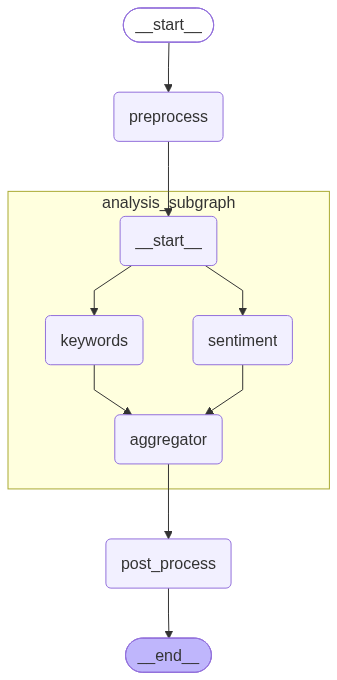

In [13]:
# ----- 父图: 直接嵌入子图作为节点 -----
def preprocess(state: ParentState):
    print(f"  [父图-预处理] 收到: {state['input_text'][:40]}...")
    return {"preprocessed": state["input_text"]}

def post_process(state: ParentState):
    print(f"  [父图-后处理] 子图结果: {state['result']}")
    return {"final_output": f"✅ 处理完成: {state['result']}"}

# 🔑 关键：直接把编译好的子图传给 add_node
parent_graph = (
    StateGraph(ParentState)
    .add_node("preprocess", preprocess)
    .add_node("analysis_subgraph", analysis_subgraph)  # 子图作为节点！
    .add_node("post_process", post_process)
    .add_edge(START, "preprocess")
    .add_edge("preprocess", "analysis_subgraph")
    .add_edge("analysis_subgraph", "post_process")
    .add_edge("post_process", END)
    .compile()
)

# 用 xray 模式可以看到子图内部结构
print("\n=== XRay模式（展开子图内部）===")
display_graph(parent_graph, xray=True)

## 6.2 包装调用

子图保持不变


=== XRay模式（展开子图内部）===


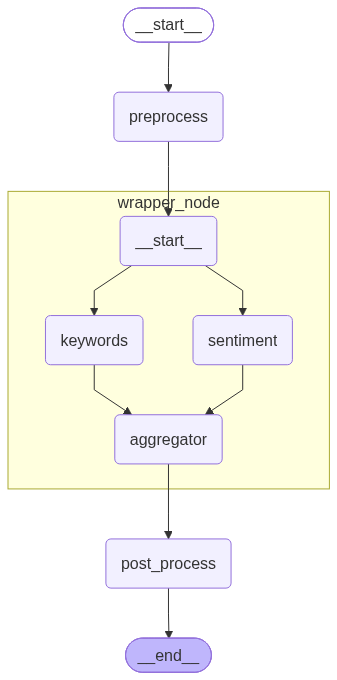

In [14]:

class ParentStateV2(TypedDict):
    query: str     # 无法共享，父调用子时直接会传递给子图的input_text
    answer: str         # 无法共享，子返回result结果时，需手动传给父图
    preprocessed: str
    final_output: str

def wrapper_node(state: ParentStateV2):
    """在包装函数内手动做 State 映射"""
    # 父→子：手动映射
    sub_result = analysis_subgraph.invoke({"input_text": state["query"]})

    # 子→父：手动映射
    return {"answer": f"包装调用结果: {sub_result['result']}"}

def preprocess(state: ParentStateV2):
    print(f"  [父图-预处理] 收到: {state['query'][:40]}...")
    return {"preprocessed": state["query"]}

def post_process(state: ParentStateV2):
    print(f"  [父图-后处理] 子图结果: {state['answer']}")
    return {"final_output": f"✅ 处理完成: {state['answer']}"}

# 🔑 关键：直接把编译好的子图传给 add_node
parent_graph_v2 = (
    StateGraph(ParentStateV2)
    .add_node("preprocess", preprocess)
    #.add_node("analysis_subgraph", analysis_subgraph)
    .add_node("wrapper_node", wrapper_node)
    .add_node("post_process", post_process)
    .add_edge(START, "preprocess")
    .add_edge("preprocess", "wrapper_node")
    .add_edge("wrapper_node", "post_process")
    .add_edge("post_process", END)
    .compile()
)

# 用 xray 模式可以看到子图内部结构
print("\n=== XRay模式（展开子图内部）===")
display_graph(parent_graph_v2, xray=True)

# 7. 总结

| 模式 | API | 原理 | 典型场景 |
|------|-----|------|----------|
| Prompt Chaining | `add_edge` 串联 + `add_conditional_edges` 做门控 | 每个LLM输出作下一个LLM输入，中间可插入质检 | 写作流程、翻译+校对、分步推理 |
| Routing | `add_conditional_edges(node, router, mapping)` | router函数返回节点名，mapping映射到实际节点 | 意图路由、权限分流、LLM工具调用判断 |
| Parallelization | 多条`add_edge`指向不同目标 | 节点间无依赖即可并行，需要reducer合并结果 | 同时查多个数据源、并行LLM调用 |
| Orchestrator-Worker | `add_conditional_edges` + `Send` API | 动态生成Send列表，并行分发到同一节点不同State | 批量处理、子问题分解、分布式搜索 |
| Evaluator-Optimizer | 条件边回环 + 评估器门控 | 生成→评估→不达标带反馈重写，达标则退出 | 文案优化、代码审查、翻译质量提升 |
| 子图嵌套 | `add_node("name", compiled_subgraph)` 或包装调用 | 子图独立管理内部State和控制流，父图复用完整流程 | 复杂流程分层、可复用流程组件 |

**核心要点**

1. **Prompt Chaining 是最简单的编排** — 串联LLM调用，中间加入门控检查，形成可验证的流水线
2. **路由是智能的基础** — Agent通过add_conditional_edges根据State动态选择路径
3. **并行提升性能** — 无依赖的节点可并行执行，用operator.add等reducer合并结果
4. **Orchestrator-Worker** — 动态任务拆分与并行执行，是智能与效率的结合，需要Send API
5. **Evaluator-Optimizer保障质量** — 生成→评估→反馈→重写循环，直到达标
6. **子图实现分层设计** — 复杂流程拆为独立子图，add_node(graph)直接嵌入，共享State自动映射

**模式选择指南**

- 确定步骤顺序 → Prompt Chaining
- 存在不同领域的Node → 智能路由(Routing)
- 多个独立任务加速 → 并行执行(Parallelization)
- 复杂任务动态拆分和性能提升 → Orchestrator-Worker(Send)
- 需要迭代优化质量 → Evaluator-Optimizer
- 流程太长需要拆解 → 子图嵌套